

## Learning Objectives

Prepared by Assoc. Prof. Dorien Herremans, based on Fares Sayah.

By the end of this module you will:

- Understand vector search strategies and how to evaluate search results
- Understand the utility of vector databases
- Differentiate between vector databases, vector libraries, and vector plugins
- Learn best practices for when to use vector stores and how to improve search-retrieval performance


## How do language models learn knowledge?

Through model training or fine-tuning

Through model inputs
> - Insert knowledge or context into the input
> - Ask the LM to incorporate the context in its output

How do we use vectors to search and provide relevant context to LMs?

Passing context to LMs helps factual recall
- Fine-tuning is usually better-suited to teach a model specialized tasks
- Passing context as model inputs improve factual recall. Downsides: Context length limitation, Longer context = higher API costs = longer processing times

We represent words with vectors.

## Use cases of vector databases

- Similarity search: text, images, audio
> - De-duplication
> - Semantic match, rather than keyword match!
> - Very useful for knowledge-based Q/A

- Recommendation engines
> - Spotify uses vector search to recommend podcast episodes

- Finding security threats
> - Vectorizing virus binaries and finding anomalies

## Search and Retrieval-Augmented Generation - The RAG workflow

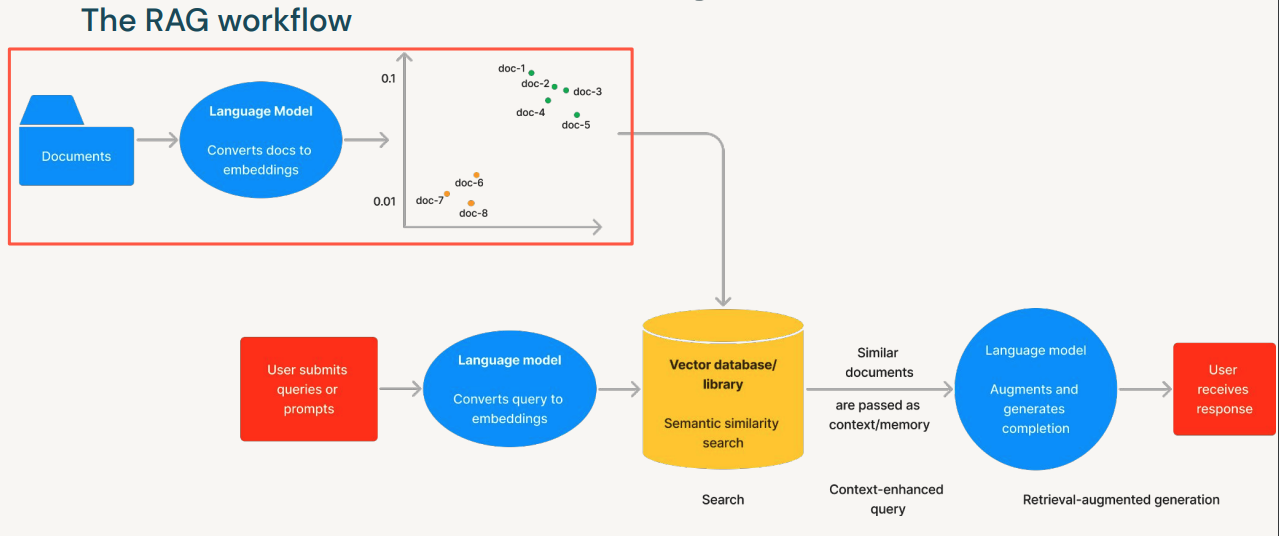


## How does vector search work?

Vector search strategies:
- K-nearest neighbors (KNN)
- Approximate nearest neighbors (ANN)
> - Trade accuracy for speed gains
> - Examples of indexing algorithms: Tree-based - ANNOY by Spotify, Proximity graphs - HNSW, Clustering - FAISS by Facebook, Hashing - LSH, Vector compression: SCaNN by Google

## How to measure if 2 vectors are similar?
- Distance metrics: The higher the metric, the less similar (L1 (Manhattan) distance, L2 (Euclidean) distance)
- Similarity metrics: The higher the metric, the more similar (Cosine Similarity)

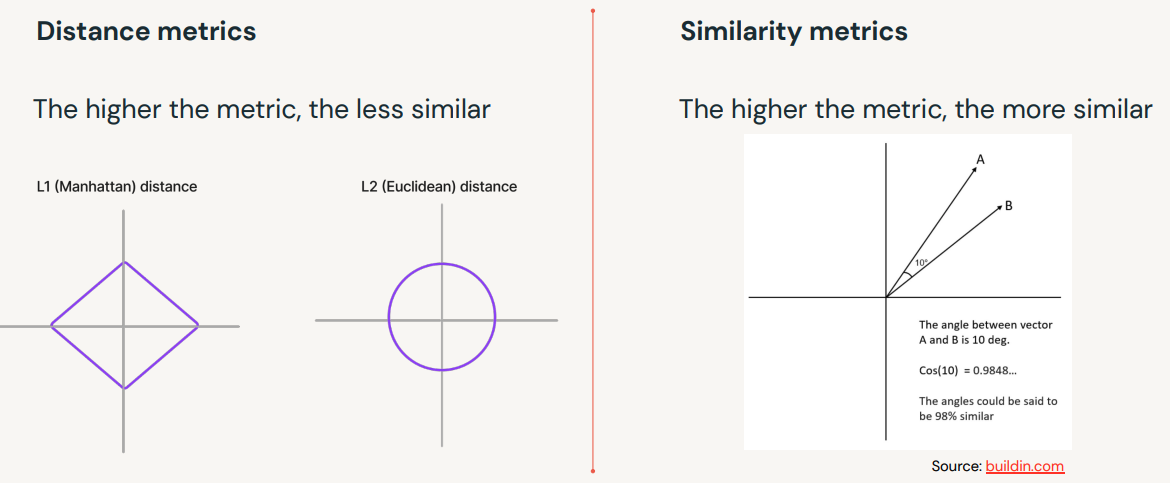

## Compressing vectors with Product Quantization

PQ stores vectors with fewer bytes.

Quantization = representing vectors to a smaller set of vectors.

Trade off between recall and memory saving

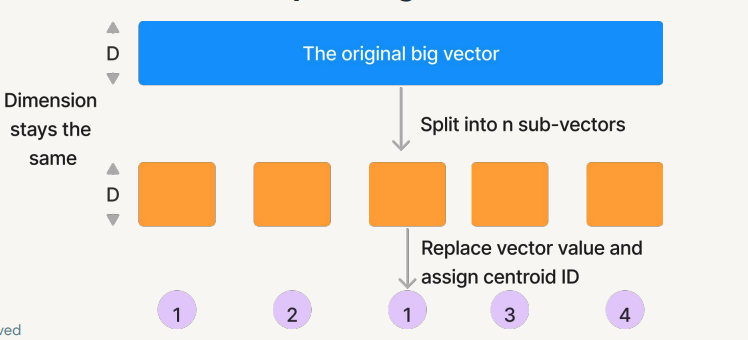

## FAISS: Facebook AI Similarity Search

Forms clusters of dense vectors and conducts Product Quantization

- Compute Euclidean distance between all points and query vector
- Given a query vector, identify which cell it belongs to
- Find all other vectors belonging to that cell
- Limitation: Not good with sparse vectors (refer to GitHub issue)

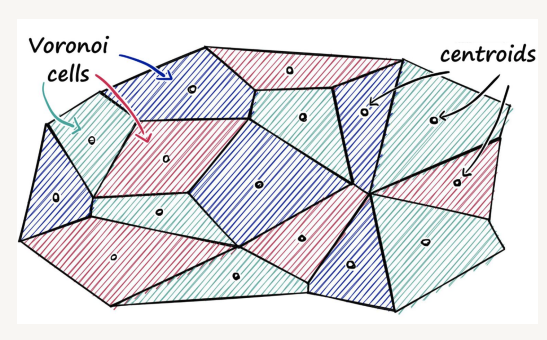



# Embeddings, Vector Databases, and Search

 Converting text into embedding vectors is the first step to any text processing pipeline. As the amount of text gets larger, there is often a need to save these embedding vectors into a dedicated vector index or library, so that developers won't have to recompute the embeddings and the retrieval process is faster. We can then search for documents based on our intended query and pass these relevant documents into a language model (LM) as additional context. We also refer to this context as supplying the LM with "state" or "memory". The LM then generates a response based on the additional context it receives!

 In this notebook, we will implement the full workflow of text vectorization, vector search, and question answering workflow. While we use [FAISS](https://faiss.ai/) (vector library) and [ChromaDB](https://docs.trychroma.com/) (vector database), and a Hugging Face model, know that you can easily swap these tools out for your preferred tools or models!

 <img src="https://files.training.databricks.com/images/llm/updated_vector_search.png" width=1000 target="_blank" >

 ### Learning Objectives
 1. Implement the workflow of reading text, converting text to embeddings, saving them to FAISS and ChromaDB
 2. Query for similar documents using FAISS and ChromaDB
 3. Apply a Hugging Face language model for question answering!


In [ ]:
# FAISS
!pip install -q faiss-cpu #==1.7.4

# Chroma + Pydantic
!pip install -q chromadb==0.3.21 pydantic==1.10.26

# OpenTelemetry (for Chroma logging)
!pip install -q opentelemetry-api==1.25.0 opentelemetry-sdk==1.25.0

# Sentence Transformers (for embeddings)
!pip install -q sentence-transformers


In Colab you might need to retart your environment here:

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
! mkdir cache

## Step 1: Reading data

In this section, we are going to use the data on <a href="https://newscatcherapi.com/" target="_blank">news topics collected by the NewsCatcher team</a>, who collect and index news articles and release them to the open-source community. The dataset can be downloaded from <a href="https://www.kaggle.com/kotartemiy/topic-labeled-news-dataset" target="_blank">Kaggle</a>.


In [ ]:
!wget -O data.zip "https://github.com/dorienh/drop/raw/refs/heads/main/labelled_newscatcher_dataset.csv.zip"
!unzip data.zip

--2026-03-31 09:38:49--  https://github.com/dorienh/drop/raw/refs/heads/main/labelled_newscatcher_dataset.csv.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dorienh/drop/refs/heads/main/labelled_newscatcher_dataset.csv.zip [following]
--2026-03-31 09:38:50--  https://raw.githubusercontent.com/dorienh/drop/refs/heads/main/labelled_newscatcher_dataset.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9909326 (9.5M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   9.45M  --.-KB/s    in 0.03s   

2026-03-31 09:38:50 (331 MB/s) - ‘data.zip’ save

In [ ]:
import pandas as pd

pdf = pd.read_csv("labelled_newscatcher_dataset.csv", sep=";")
pdf["id"] = pdf.index
display(pdf)

,topic,link,domain,published_date,title,lang,id
0,SCIENCE,https://www.eurekalert.org/pub_releases/2020-0...,eurekalert.org,2020-08-06 13:59:45,A closer look at water-splitting's solar fuel ...,en,0
1,SCIENCE,https://www.pulse.ng/news/world/an-irresistibl...,pulse.ng,2020-08-12 15:14:19,"An irresistible scent makes locusts swarm, stu...",en,1
2,SCIENCE,https://www.express.co.uk/news/science/1322607...,express.co.uk,2020-08-13 21:01:00,Artificial intelligence warning: AI will know ...,en,2
3,SCIENCE,https://www.ndtv.com/world-news/glaciers-could...,ndtv.com,2020-08-03 22:18:26,Glaciers Could Have Sculpted Mars Valleys: Study,en,3
4,SCIENCE,https://www.thesun.ie/tech/5742187/perseid-met...,thesun.ie,2020-08-12 19:54:36,Perseid meteor shower 2020: What time and how ...,en,4
...,...,...,...,...,...,...,...
108769,NATION,https://www.vanguardngr.com/2020/08/pdp-govern...,vanguardngr.com,2020-08-08 02:40:00,PDP governors’ forum urges security agencies t...,en,108769
108770,BUSINESS,https://www.patentlyapple.com/patently-apple/2...,patentlyapple.com,2020-08-08 01:27:12,"In Q2-20, Apple Dominated the Premium Smartpho...",en,108770
108771,HEALTH,https://www.belfastlive.co.uk/news/health/coro...,belfastlive.co.uk,2020-08-12 17:01:00,Coronavirus Northern Ireland: Full breakdown s...,en,108771
108772,ENTERTAINMENT,https://www.thenews.com.pk/latest/696364-paul-...,thenews.com.pk,2020-08-05 04:59:00,Paul McCartney details post-Beatles distress a...,en,108772


 ## Vector Library: FAISS

Vector libraries are often sufficient for small, static data. Since it's not a full-fledged database solution, it doesn't have the CRUD (Create, Read, Update, Delete) support. Once the index has been built, if there are more vectors that need to be added/removed/edited, the index has to be rebuilt from scratch.

That said, vector libraries are easy, lightweight, and fast to use. Examples of vector libraries are [FAISS](https://faiss.ai/), [ScaNN](https://github.com/google-research/google-research/tree/master/scann), [ANNOY](https://github.com/spotify/annoy), and [HNSM](https://arxiv.org/abs/1603.09320).

 FAISS has several ways for similarity search: L2 (Euclidean distance), cosine similarity. You can read more about their implementation on their [GitHub](https://github.com/facebookresearch/faiss/wiki/Getting-started#searching) page or [blog post](https://engineering.fb.com/2017/03/29/data-infrastructure/faiss-a-library-for-efficient-similarity-search/). They also published their own [best practice guide here](https://github.com/facebookresearch/faiss/wiki/Guidelines-to-choose-an-index).

 If you'd like to read up more on the comparisons between vector libraries and databases, [here is a good blog post](https://weaviate.io/blog/vector-library-vs-vector-database#feature-comparison---library-versus-database).

The overall workflow of FAISS is captured in the diagram below.

 <img src="https://miro.medium.com/v2/resize:fit:1400/0*ouf0eyQskPeGWIGm" width=700>

Source: [How to use FAISS to build your first similarity search by Asna Shafiq](https://medium.com/loopio-tech/how-to-use-faiss-to-build-your-first-similarity-search-bf0f708aa772).


In [ ]:
from sentence_transformers import InputExample
# !pip install ipywidgets

pdf_subset = pdf.head(1000)

def example_create_fn(doc1: pd.Series) -> InputExample:
    """
    Helper function that outputs a sentence_transformer guid, label, and text
    """
    return InputExample(texts=[doc1])

faiss_train_examples = pdf_subset.apply(
    lambda x: example_create_fn(x["title"]), axis=1
).tolist()

In [ ]:
faiss_train_examples[:10]

This shows the class name (InputExample) and the memory address.

### Step 2: Vectorize text into embedding vectors
We will be using `Sentence-Transformers` [library](https://www.sbert.net/) to load a language model to vectorize our text into embeddings. The library hosts some of the most popular transformers on [Hugging Face Model Hub](https://huggingface.co/sentence-transformers).


Here, we are using the `model = SentenceTransformer("all-MiniLM-L6-v2")` to generate embeddings.


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    cache_folder="../working/cache"
)

faiss_title_embedding = model.encode(pdf_subset.title.values.tolist(), batch_size=32,
    show_progress_bar=True)
len(faiss_title_embedding), len(faiss_title_embedding[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)

We selected 1000 vectors, and they are each embedded with len 384.

### Step 3: Saving embedding vectors to FAISS index
Below, we create the FAISS index object based on our embedding vectors, normalize vectors, and add these vectors to the FAISS index.

Later then FAISS IndexFlatIP (inner product) works as cosine similarity if vectors are normalized.

- `IndexFlatIP(d)` → flat inner-product index with dimension d.
- `IndexIDMap` allows you to assign your own integer IDs instead of relying on FAISS row numbers.
- `_with_ids(embeddings, ids)` → embeddings now map to your DataFrame ids.

Faiss index: A data structure optimized to store vectors and compute similarities very fast

In [ ]:
import numpy as np
import faiss

pdf_to_index = pdf_subset.set_index(["id"], drop=False)
id_index = np.array(pdf_to_index.id.values).flatten().astype("int")

# content_encoded_normalized = faiss_title_embedding.copy()
# faiss.normalize_L2(content_encoded_normalized) # normalize embeddings

faiss.normalize_L2(faiss_title_embedding)
content_encoded_normalized = faiss_title_embedding

# Index1DMap translates search results to IDs: https://faiss.ai/cpp_api/file/IndexIDMap_8h.html#_CPPv4I0EN5faiss18IndexIDMapTemplateE
# The IndexFlatIP below builds index
index_content = faiss.IndexIDMap(faiss.IndexFlatIP(len(faiss_title_embedding[0])))
index_content.add_with_ids(content_encoded_normalized, id_index)

In [ ]:
index_content

<faiss.swigfaiss_avx512.IndexIDMap; proxy of <Swig Object of type 'faiss::IndexIDMapTemplate< faiss::Index > *' at 0x7ea57c0b2370> >

## Step 4: Search for relevant documents

We define a search function below to first vectorize our query text, and then search for the vectors with the closest distance.


In [ ]:
def search_content(query, pdf_to_index, k=3):
    query_vector = model.encode([query])
    faiss.normalize_L2(query_vector)

    # We set k to limit the number of vectors we want to return
    top_k = index_content.search(query_vector, k)
    ids = top_k[1][0].tolist()
    similarities = top_k[0][0].tolist()
    results = pdf_to_index.loc[ids] #Uses IDs to fetch rows from your DataFrame - This is why IndexIDMap was important
    results["similarities"] = similarities
    return results

In [ ]:
display(search_content("animal", pdf_to_index, k=5))

,topic,link,domain,published_date,title,lang,id,similarities
id,,,,,,,,
176,TECHNOLOGY,https://www.pushsquare.com/news/2020/08/random...,pushsquare.com,2020-08-03 16:30:00,Random: You Can Pick Up and Pet Cats in Assass...,en,176,0.391902
975,HEALTH,https://www.news-medical.net/news/20200813/Res...,news-medical.net,2020-08-13 05:18:00,Researchers explore social behavior of animals...,en,975,0.376784
99,TECHNOLOGY,https://www.gematsu.com/2020/08/ghostwire-toky...,gematsu.com,2020-08-07 16:43:13,Ghostwire: Tokyo confirms dog petting,en,99,0.344059
928,SCIENCE,https://www.thecut.com/2020/08/scientists-say-...,thecut.com,2020-08-04 12:52:00,Just Let This Lizard Be a Dinosaur,en,928,0.317387
762,SCIENCE,https://af.reuters.com/article/worldNews/idAFK...,af.reuters.com,2020-08-13 16:51:00,'Secret' life of sharks: Study reveals their s...,en,762,0.295497


Tada! Now you can query for similar content! Notice that you did not have to configure any database networks beforehand nor pass in any credentials. FAISS works locally with your code.

Let's load an LLM for answering our questions.


In [ ]:

from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import pipeline
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" #distilgpt2
pipe = pipeline("text-generation", model=model_name, max_new_tokens=150)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## Adding re-ranking step


In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
question = "Summarize the recent developments in space exploration."

# Use the search_content function
retrieved_content_df = search_content(question, pdf_to_index, k=5)
retrieved_content = retrieved_content_df['title'].tolist()
similarities = retrieved_content_df['similarities'].tolist()

print("Initial retrieved titles:")
for r in retrieved_content:
    print("-", r)

Initial retrieved titles:
- Scientific research to widen on ISS as SpaceX eyes commercial crew missions
- Orbital space tourism set for rebirth in 2021
- The scramble for space at Earth’s outer limits
- Beck teams up with NASA and AI for 'Hyperspace' visual album experience
- Major Goal is to Identify Planets that Could Support Life: NASA


In [ ]:

pairs = [[question, doc] for doc in retrieved_content]
scores = reranker.predict(pairs)

reranked = [doc for _, doc in sorted(zip(scores, retrieved_content), reverse=True)]

print("After re-ranking:")
for r in reranked:
    print("-", r)

After re-ranking:
- Orbital space tourism set for rebirth in 2021
- Scientific research to widen on ISS as SpaceX eyes commercial crew missions
- The scramble for space at Earth’s outer limits
- Major Goal is to Identify Planets that Could Support Life: NASA
- Beck teams up with NASA and AI for 'Hyperspace' visual album experience


## Compare Without vs With RAG

In [ ]:
# 4. GENERATE
context = "\n".join(reranked)  # use reranked, not original order

prompt = f"""<|system|>
You are a helpful assistant. Summarize using the context only. If unsure, say 'I don't know'.</s>
<|user|>
Context:
{context}

{question}</s>
<|assistant|>
"""

print("WITHOUT RAG:")
print(pipe(question)[0]["generated_text"])

print("\nWITH RAG:")
print(pipe(prompt)[0]["generated_text"])

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


WITHOUT RAG:


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summarize the recent developments in space exploration.

WITH RAG:
<|system|>
You are a helpful assistant. Summarize using the context only. If unsure, say 'I don't know'.</s>
<|user|>
Context:
Orbital space tourism set for rebirth in 2021
Scientific research to widen on ISS as SpaceX eyes commercial crew missions
The scramble for space at Earth’s outer limits
Major Goal is to Identify Planets that Could Support Life: NASA
Beck teams up with NASA and AI for 'Hyperspace' visual album experience

Summarize the recent developments in space exploration.</s>
<|assistant|>
The context provided suggests that there are new developments in space exploration in 2021, including the potential launch of commercial crew missions and the re-entry of the International Space Station (ISS) for scientific research. Additionally, NASA has teamed up with artificial intelligence for a visual album experience called "Hyperspace." The scramble for space at Earth's outer limits is also highlighted.


## 9. Failure Case Demonstration

In [ ]:
# 5. TRICK QUESTION - hallucination test
trick_question = "Which country built the first Mars city?"

# Retrieve context for the trick question
trick_df = search_content(trick_question, pdf_to_index, k=5)
trick_docs = trick_df['title'].tolist()

# Rerank
trick_pairs = [[trick_question, doc] for doc in trick_docs]
trick_scores = reranker.predict(trick_pairs)
trick_reranked = [doc for _, doc in sorted(zip(trick_scores, trick_docs), reverse=True)]
trick_context = "\n".join(trick_reranked)

# TinyLlama chat template
trick_prompt = f"""<|system|>
You are a factual assistant. Use only the provided context. If the answer is not in the context, say 'I don't know'.</s>
<|user|>
Context:
{trick_context}

{trick_question}</s>
<|assistant|>
"""

print("WITHOUT RAG:")
print(pipe(trick_question)[0]["generated_text"])

print("\nWITH RAG:")
output = pipe(trick_prompt)[0]["generated_text"]
# Strip the prompt from the output — TinyLlama includes it by default
answer = output.split("<|assistant|>")[-1].strip()
print(answer)

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


WITHOUT RAG:
Which country built the first Mars city?

WITH RAG:
The given context suggests that the answer is Australia. The sentence "Australia's small yet crucial part in the mission to find life on Mars" implies that Australia is a country that has played a significant role in the search for life on Mars.

The sentence "The Majestic Valleys of Mars May Not Have Been Carved by Rivers After All" suggests that the Valleys on Mars may not have been carved by rivers, rather, they may have been created by geological processes.

"Glaciers Could Have Sculpted Mars Valleys: Study" suggests that glaciers on Mars could have sculpted the valleys.

"NASA Saved Its Mars Mole


Up until now, we haven't done the last step of conducting Q/A with a language model yet. We are going to demonstrate this with Chroma, a vector database.


## Vector Database: Chroma

Chroma is an open-source embedding database. The company just raised its [seed funding in April 2023](https://www.trychroma.com/blog/seed) and is quickly becoming popular to support LLM-based applications.


In [ ]:
# !pip list | grep -E "pydantic|chromadb"
# !pip uninstall -y chromadb pydantic-settings pydantic_core
!pip install 'posthog<6.0.0'

In [ ]:
import chromadb

# from pydantic_settings import BaseSettings

chroma_client = chromadb.Client()

In [ ]:
import chromadb
import sentence_transformers

print(f"ChromaDB version: {chromadb.__version__}")
print(f"Sentence-Transformers version: {sentence_transformers.__version__}")

ChromaDB version: 0.3.21
Sentence-Transformers version: 5.3.0


### Chroma Concept: Collection

Chroma `collection` is akin to an index that stores one set of your documents.

According to the [docs](https://docs.trychroma.com/getting-started):
> Collections are where you will store your embeddings, documents, and additional metadata

The nice thing about ChromaDB is that if you don't supply a model to vectorize text into embeddings, it will automatically load a default embedding function, i.e. `SentenceTransformerEmbeddingFunction`. It can handle tokenization, embedding, and indexing automatically for you. If you would like to change the embedding model, read [here on how to do that](https://docs.trychroma.com/embeddings). TLDR: you can add an optional `model_name` argument.

You can read [the documentation here](https://docs.trychroma.com/usage-guide#using-collections) on rules for collection names.


In [ ]:
collection_name = "my_news"

# If you have created the collection before, you need to delete the collection first
if len(chroma_client.list_collections()) > 0 and collection_name in [chroma_client.list_collections()[0].name]:
    chroma_client.delete_collection(name=collection_name)

print(f"Creating collection: '{collection_name}'")
collection = chroma_client.create_collection(name=collection_name)

Creating collection: 'my_news'


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Step 1: Add data to collection

Since we are re-using the same data, we can skip the step of reading data. As mentioned in the text above, Chroma can take care of text vectorization for us, so we can directly add text to the collection and Chroma will convert the text into embeddings behind the scene. Chroma uses a default embedding model. This is fine for demo. In production you will want to control this more. If you wanted to specify embedding model, you could do it like this:
```
from chromadb.utils import embedding_functions

embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-small"
)

collection = chroma_client.create_collection(
    name="my_news",
    embedding_function=embedding_function
)
```


In [ ]:
display(pdf_subset)

,topic,link,domain,published_date,title,lang,id
0,SCIENCE,https://www.eurekalert.org/pub_releases/2020-0...,eurekalert.org,2020-08-06 13:59:45,A closer look at water-splitting's solar fuel ...,en,0
1,SCIENCE,https://www.pulse.ng/news/world/an-irresistibl...,pulse.ng,2020-08-12 15:14:19,"An irresistible scent makes locusts swarm, stu...",en,1
2,SCIENCE,https://www.express.co.uk/news/science/1322607...,express.co.uk,2020-08-13 21:01:00,Artificial intelligence warning: AI will know ...,en,2
3,SCIENCE,https://www.ndtv.com/world-news/glaciers-could...,ndtv.com,2020-08-03 22:18:26,Glaciers Could Have Sculpted Mars Valleys: Study,en,3
4,SCIENCE,https://www.thesun.ie/tech/5742187/perseid-met...,thesun.ie,2020-08-12 19:54:36,Perseid meteor shower 2020: What time and how ...,en,4
...,...,...,...,...,...,...,...
995,TECHNOLOGY,https://www.androidcentral.com/mate-40-will-be...,androidcentral.com,2020-08-07 17:12:33,The Mate 40 will be the last Huawei phone with...,en,995
996,SCIENCE,https://www.cnn.com/2020/08/17/africa/stone-ag...,cnn.com,2020-08-17 17:10:00,"Early humans knew how to make comfy, pest-free...",en,996
997,HEALTH,https://www.tenterfieldstar.com.au/story/68776...,tenterfieldstar.com.au,2020-08-13 03:26:06,Regional Vic set for virus testing blitz,en,997
998,HEALTH,https://news.sky.com/story/coronavirus-trials-...,news.sky.com,2020-08-13 13:22:58,Coronavirus: Trials of second contact-tracing ...,en,998


Each document must have a unique `id` associated with it and it is up to you to check that there are no duplicate ids.

Adding data to collection will take some time to run, especially when there is a lot of data. In the cell below, we intentionally write only a subset of data to the collection to speed things up.


In [ ]:
collection.add(
    documents=pdf_subset["title"][:100].tolist(),
    metadatas=[{"topic": topic} for topic in pdf_subset["topic"][:100].tolist()],
    ids=[f"id{x}" for x in range(100)],
)

### Step 2: Query for 10 relevant documents on "space"

We will return 10 most relevant documents. You can think of `10` as 10 nearest neighbors. You can also change the number of results returned as well.


In [ ]:
import json

results = collection.query(query_texts=["space"], n_results=10)

print(json.dumps(results, indent=4))

{
    "ids": [
        [
            "id72",
            "id7",
            "id30",
            "id26",
            "id23",
            "id76",
            "id69",
            "id40",
            "id47",
            "id75"
        ]
    ],
    "embeddings": null,
    "documents": [
        [
            "Beck teams up with NASA and AI for 'Hyperspace' visual album experience",
            "Orbital space tourism set for rebirth in 2021",
            "NASA drops \"insensitive\" nicknames for cosmic objects",
            "\u2018It came alive:\u2019 NASA astronauts describe experiencing splashdown in SpaceX Dragon",
            "Hubble Uses Moon As \u201cMirror\u201d to Study Earth\u2019s Atmosphere \u2013 Proxy in Search of Potentially Habitable Planets Around Other Stars",
            "Australia's small yet crucial part in the mission to find life on Mars",
            "NASA Astronauts in SpaceX Capsule Splashdown in Gulf Of Mexico",
            "SpaceX's Starship spacecraft saw 150 mete

### Bonus: Add filter statement

In addition to conducting relevancy search, we can also add filter statements. Refer to the [documentation](https://docs.trychroma.com/usage-guide#using-where-filters) for more information.


In [ ]:
collection.query(query_texts=["space"], where={"topic": "SCIENCE"}, n_results=10)

{'ids': [['id7',
   'id30',
   'id26',
   'id23',
   'id76',
   'id69',
   'id40',
   'id47',
   'id75',
   'id52']],
 'embeddings': None,
 'documents': [['Orbital space tourism set for rebirth in 2021',
   'NASA drops "insensitive" nicknames for cosmic objects',
   '‘It came alive:’ NASA astronauts describe experiencing splashdown in SpaceX Dragon',
   'Hubble Uses Moon As “Mirror” to Study Earth’s Atmosphere – Proxy in Search of Potentially Habitable Planets Around Other Stars',
   "Australia's small yet crucial part in the mission to find life on Mars",
   'NASA Astronauts in SpaceX Capsule Splashdown in Gulf Of Mexico',
   "SpaceX's Starship spacecraft saw 150 meters high",
   'NASA’s InSight lander shows what’s beneath Mars’ surface',
   'Alien base on Mercury: ET hunters claim to find huge UFO',
   'SpaceX Crew-1 mission with NASA, first fully operational crewed mission to space to launch in October']],
 'metadatas': [[{'topic': 'SCIENCE'},
   {'topic': 'SCIENCE'},
   {'topic': '

### Bonus: Update data in a collection

Unlike a vector library, vector databases support changes to the data so we can update or delete data.

Indeed, we can update or delete data in a Chroma collection.


In [ ]:
collection.delete(ids=["id0"])

[UUID('6bf03ce6-560f-4ebf-9c48-da563827484d')]

The record with `ids=0` is no longer present.

In [ ]:
collection.get(
    ids=["id0"],
)

{'ids': [], 'embeddings': None, 'documents': [], 'metadatas': []}

We can also update a specific data point.


In [ ]:
collection.get(
    ids=["id2"],
)

{'ids': ['id2'],
 'embeddings': None,
 'documents': ['Artificial intelligence warning: AI will know us better than we know ourselves'],
 'metadatas': [{'topic': 'SCIENCE'}]}

In [ ]:
collection.update(
    ids=["id2"],
    metadatas=[{"topic": "TECHNOLOGY"}],
)


In [ ]:
collection.get(
    ids=["id2"],
)

{'ids': ['id2'],
 'embeddings': None,
 'documents': ['Artificial intelligence warning: AI will know us better than we know ourselves'],
 'metadatas': [{'topic': 'TECHNOLOGY'}]}

Now let's load an instruction tuned LLM to answer the user's question.

In [ ]:
# very large model
#  from transformers import AutoTokenizer, AutoModelForCausalLM
# import torch

# model_id = "nomic-ai/gpt4all-j"  # or "nomic-ai/gpt4all-j-q4_0"
# # model_id = "tiiuae/falcon-7b-instruct"
# cache_dir = "../working/cache"

# # Load tokenizer and model
# tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=cache_dir)
# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     cache_dir=cache_dir,
#     device_map="auto",  # automatically splits across GPU/CPU if needed
# )

# # Detect main device for inputs
# device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
# print(f"Main device for input tensors: {device}")


# # Test generation
# prompt = "Summarize NASA's latest space developments."
# inputs = tokenizer(prompt, return_tensors="pt").to(device)

# # Generate text
# outputs = model.generate(**inputs, max_new_tokens=200)
# print(tokenizer.decode(outputs[0], skip_special_tokens=True))


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/285 [00:00<?, ?it/s]

GPTJForCausalLM LOAD REPORT from: nomic-ai/gpt4all-j
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...27}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...27}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/146 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Main device for input tensors: cuda
Summarize NASA's latest space developments.
NASA has been making significant progress in space exploration, including:

1. The Mars 2020 Perseverance rover, which is scheduled to launch in July 2021, will explore the Red Planet's surface and search for signs of past or present microbial life.

2. NASA's Voyager 1 spacecraft, which is currently exploring the outer solar system, is expected to reach the edge of the solar system in August 2021.

3. NASA's Cassini spacecraft, which is currently orbiting Saturn, has discovered new moons and rings, and is studying the planet's atmosphere and magnetosphere.

4. NASA's Hubble Space Telescope has been upgraded with a new camera and is now able to capture images of the universe in ultraviolet light.

5. NASA's Solar Dynamics Observatory has been launched in 2010 and is now studying the sun's activity and the effects of solar storms on Earth.

6. NASA's Mars rover, Curiosity, has been exploring the Red Planet's

## Prompt engineering for question answering

Now that we have identified documents about space from the news dataset, we can pass these documents as additional context for a language model to generate a response based on them!

We first need to pick a `text-generation` model. Below, we use a Hugging Face model. You can also use OpenAI as well, but you will need to get an Open AI token and [pay based on the number of tokens](https://openai.com/pricing).


In [ ]:
# smaller model. But worse response, in case don't have time to load the one below:

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# Detect device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():  # Apple GPU
    device = "mps"
else:
    device = "cpu"

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir="../working/cache")
lm_model = AutoModelForCausalLM.from_pretrained(model_id, cache_dir="../working/cache").to(device)

pipe = pipeline(
    "text-generation",
    model=lm_model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    device=0 if device == "cuda" else -1, # Set device to 0 for GPU, -1 for CPU
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# smaller model. But worse response, in case don't have time to load the one below:

question = "What's the latest news on space development?"
context = " ".join([f"#{str(i)}" for i in results["documents"][0]])
prompt_template = f"Given the following context:\n\n{context}\n\nAnswer the user's question: {question}\nAnswer:"

lm_response = pipe(prompt_template, return_full_text=False)
print(lm_response[0]["generated_text"]) # Extract only the generated text

Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 NASA has announced its plan to offer "hyperspace" travel to private citizens. Beck teams up with NASA and AI for "Hyperspace" visual album experience, AI-powered space tourism set for rebirth in 2021, NASA drops "insensitive" nicknames for cosmic objects, "It came alive:” NASA astronauts describe experiencing splashdown in SpaceX Dragon, Hubble uses moon as “mirror” to study Earth’s atmosphere – proxy in search of potentially habitable planets, Australia's small yet crucial part in the mission to find life on Mars, NASA astronauts in SpaceX Capsule splashdown in Gulf of Mexico, SpaceX's Starship spacecraft saw 150 meters high, NASA's InSight lander shows what's beneath Mars' surface, Alien base on Mercury: ET hunters claim to find huge UFO, "The latest news on space development"


Here's where prompt engineering, which is developing prompts, comes in. We pass in the context in our `prompt_template` but there are numerous ways to write a prompt. Some prompts may generate better results than the others and it requires some experimentation to figure out how best to talk to the model. Each language model behaves differently to prompts.

Our prompt template below is inspired from a [2023 paper on program-aided language model](https://arxiv.org/pdf/2211.10435.pdf). The authors have provided their sample prompt template [here](https://github.com/reasoning-machines/pal/blob/main/pal/prompt/date_understanding_prompt.py).

The following links also provide some helpful guidance on prompt engineering:
- [Prompt engineering with OpenAI](https://help.openai.com/en/articles/6654000-best-practices-for-prompt-engineering-with-openai-api)
- [GitHub repo that compiles best practices to interact with ChatGPT](https://github.com/f/awesome-chatgpt-prompts)


Yay, you have just completed the implementation of your first text vectorization, search, and question answering workflow (that requires prompt engineering)!

In the lab, you will apply your newly gained knowledge to a different dataset. You can also check out the optional modules on Pinecone and Weaviate to learn how to set up vector databases that offer enterprise offerings.